# Coursework Set Week 5

**Common remarks**:

* Deadline: Sunday at 23:59h for the scheduled week of this task
* <font color='red'>Keep all the information in this template unaltered!</font>

**Please fill in the following fields:**

* Name: Anna van der Vecht
* Username: amvecht
* Student number: s6390382
* Group (AS1, etc.): AS5

-----

In [1]:
totalpoints = currentpoints = 0

### Plotting a galaxy rotation curve from data in a text file (4 pt) <font color='red'><b>COURSEWORK</b></font>

This qustion you will use data from an observation of NGC 6946. The stellar mass of NGC 6946 is $M_* = 2\times10^{10} M_{\odot}$, where $M_{\odot}$ represent *solar mass (the mass of the Sun)*. 

* Copy/download the file [rotcur.dat](https://www.astro.rug.nl/intranet/courses/PROGNUMNEW/latest/DATA/rotcur.dat). This text file contains the output of a program that calculates rotation curves. Examine its contents on the Linux command line with a pager like ``more`` or in an editor so that you know what the columns represent.
* Write a program, that reads the columns `radius` and `rotation velocity`. Radii are in **kpc** and velocities in **km/s**.
* Create a line plot where the $x$-axis represents the radius and the $y$-axis represents the rotation velocity.
* Calculate the Keplerian rotation curve using $v=\sqrt{\frac{GM}{r}}$
* Create and save a text file called ``keplerian_curve.txt`` using ``np.savetxt()``.
* Using ``np.loadtxt()`` to load your Keplerian curve and plot it together with the observation data.
* Force the lower limit of the $y$-axis range to 0 and the upper limit to maximal values of the Keplerian curve.
* Annotate the plot with relevant information.
* Make comment about your observation.

**Answers**:

<function matplotlib.pyplot.show(close=None, block=None)>

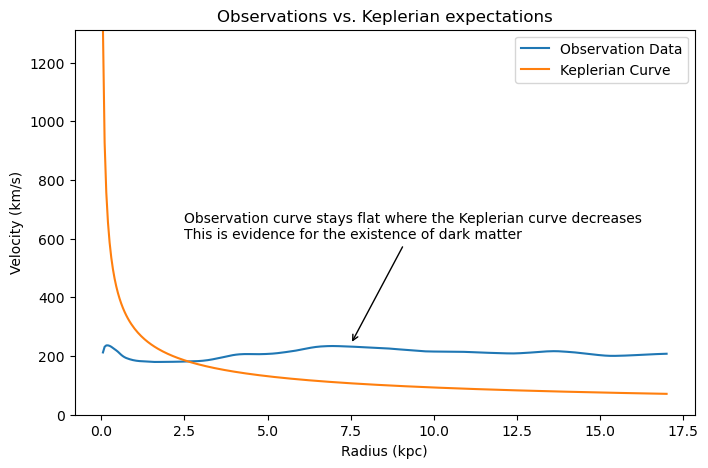

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.constants import G

#The file shows 2 columns, one with R(kpc) so the radius, and one with V(km/s) so the velocity
radius, velocity = np.loadtxt("rotcur.dat.txt", unpack=True) # Load the text file define first collumn as radius and second as velocity (loadtxt will automatically ignore starting comments with #)
radius, velocity = radius[1:], velocity[1:]
# Used [1:] for radius and velocity since first value in collumns will result in a division by 0


#Plot radius on x-axis and rotation velocity on y-axis
plt.figure(figsize=(8,5))
plt.plot(radius, velocity, label="Observation Data") # Use original radius in kpc and velocity in km/s


Mstar = 2e10 # Mass of the star in solar masses
Msun = 1.989e30 # Mass of sun according to NASA: https://solarsystem.nasa.gov/sun-by-the-numbers/
Mstar = 2e10 *Msun # Convert mass of star to kg instead of having it in solar masses


#For v = sqrt(GM/r) we need radius in meters and then convert the resulting velocity to km/s
r = radius * 3.086e19 # use conversion constant to convert radius to meters
vms = np.sqrt(G * Mstar / r) #calculate v with given formula
v = vms /1000 #Convert from m/s to km/s


np.savetxt("keplerian_curve.txt", np.column_stack((radius, v))) # add the velocity and radius to the text file using numpy's column stack feature to add both columns
r_kepler, v_kepler = np.loadtxt("keplerian_curve.txt", unpack=True) # Load data from file with first column as radius second column as velocity (just like how I added them to the file)

#Plot keplerian curve
plt.plot(r_kepler, v_kepler, label="Keplerian Curve")
plt.title("Observations vs. Keplerian expectations") # Add title
plt.xlabel("Radius (kpc)") #Label the x axis
plt.ylabel("Velocity (km/s)") # label the y axis
plt.ylim(0, np.max(v_kepler)) # Limit the range of the y-axis from 0 to the maximum of the kepler velocity (since velocity is on the y axis)
plt.legend() # Include legend in graph

plt.annotate("Observation curve stays flat where the Keplerian curve decreases\nThis is evidence for the existence of dark matter", xy=(7.5,240), xytext=(2.5,600), arrowprops=dict(arrowstyle="->"))

plt.show



In [3]:
# Leave unaltered
totalpoints += 4
currentpoints += 0.0

### Exploring image noise (3 pt)  <font color='red'><b>COURSEWORK</b></font>
   
* Create a two dimensional NumPy array with 200 rows and 300 columns filled with pixel values drawn from the normal distribution ``numpy.random.normal()`` with a mean of 0 and standard deviation 1.0.
* Use ``plt.imshow()`` to plot the image. The figure must be 8 inches wide and 4 inches high.
* Use color map ``jet`` for your image.
* Take a small two dimensional slice (e.g. 30x30 pixels) somewhere in the image and calculate the mean and standard deviation of the pixel values in your slice.
* Are this mean and standard deviation what you expected?
* Plot a histogram of all image values in 50 bins (you will need to ravel/flatten the data first). To not overlap with the previous plot, you probably need to create a new plot ``plt.figure()``. What distribution should you recognise?

**Answer**:

Mean of slice: 0.0041720944879948, Standard deviation of slice 0.975509192995886


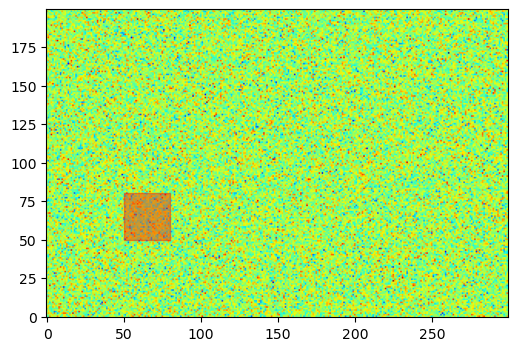

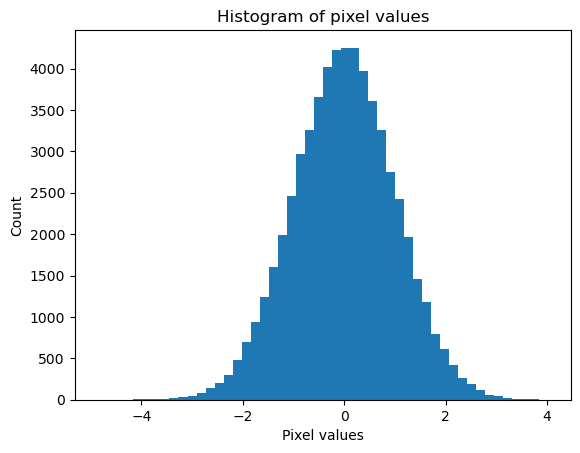

' The histogram should look like a normal/Gaussian distribution because that is what we used for the original data. '

In [14]:
import numpy as np
import matplotlib.pyplot as plt

pixels = np.random.normal(0, 1, size = (200,300)) # mean = 0, sd = 1, 200 by 300 array

plt.figure(figsize = (8,4)) #specify the width and height
plt.imshow(pixels, cmap='jet', origin='lower') #specified origin too so it is bottom left

N = 50 #lower border
M = 80 # upper border
sliced = pixels[N:M, N:M] # slice a M-N by M-N pixel area
#Optional hihglighting selected slice:
plt.fill_betweenx([N, M], N, M, color='red', alpha=0.4)

slice_mean = np.mean(sliced)
slice_sd = np.std(sliced)

print(f"Mean of slice: {slice_mean}, Standard deviation of slice {slice_sd}")
# The mean and standard deviation of the slice should be approximately the same as the mean and sd of the original data array
# As expected it is indeed around 0 for the mean and 1 for the standard deviation

#HISTOGRAM:
histdata = pixels.ravel() #Ravel the data for the histogram

#plot histogram data
plt.figure() # Start new figure for histogram
plt.hist(histdata, bins=50)
plt.title('Histogram of pixel values')
plt.xlabel('Pixel values')
plt.ylabel('Count')
plt.show()

''' The histogram should look like a normal/Gaussian distribution because that is what we used for the original data. '''

In [5]:
# Leave unaltered
totalpoints += 3
currentpoints += 0.0

### Extending the Ellipse class (6 pt) <font color='red'><b>COURSEWORK</b></font>

* Copy the code for class ``AstroEllipse`` in the section.
* Extend the class with a method that calculates and returns the area of the ellipse.
* Extend the class with a method that calculates and returns the perimeter of the ellipse (keywords: Ramanujan’s formula for perimeter of ellipse).
* Give an example of the creation of an ellipse with semi major axis equal to 3 and semi minor axis equal to 2 and call the methods for area and perimeter to show what the area and perimeter is for this ellipse.
* Add a method ``__str__()`` which returns a string with the values of the ellipse parameters (center, axes and angle) and demonstrate the method with ``print()``.
* Create a class ``MyCircle`` which inherits from class ``AstroEllipse``. The arguments for its ``__init__()`` function is a center position and a radius.
* Create a plot with three circles with random origins and radii. The circles must have different colors and the  transparency (``alpha=``) must be set to 0.5. Use the ``Axes`` object (Section 5.7) to add the circles to the plot.

**Answers**:

Area of ellipse: 18.84955592153876
Perimeter of ellipse: 15.865439589251233
AstroEllipse (center=(0, 0), semi_major=3, semi_minor=2, position_angle=30 degrees)


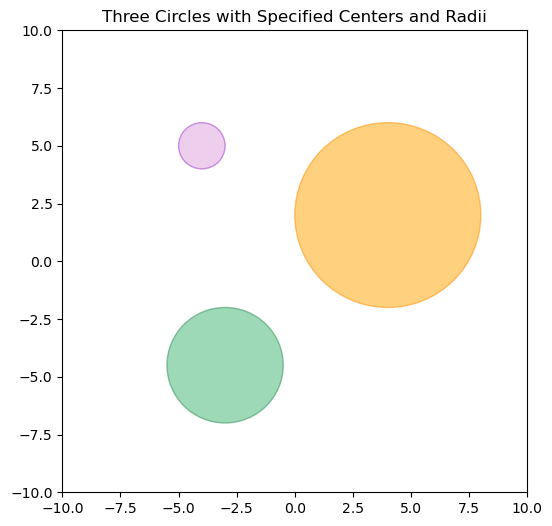

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse

class AstroEllipse(Ellipse):
    def __init__(self, xc, yc, semi_major, semi_minor, position_angle, **args):
        # We use the (sort of) astronomical angle where 'angle' defines)
        # the position angle of the major axis of a ring projected onto the sky
        # (i.e. an ellipse). This is an angle taken in anti-clockwise direction between
        # the north direction on the sky and the major axis of the receding half of the
        # galaxy (Rots 1975, astron, astrophys 45, 43).
        # Here we assume (!) north is in the positive Y direction.
        # If not, you need to correct the angle for the rotation of the image.
        # Parameter 'position_angle' enters in degrees
        assert(semi_major >= semi_minor)  # Prerequisite to make angle unambiguous
        XY = (xc, yc)                  # MPL requires center as a tuple
        angle_mpl = position_angle     # Angle for MatPlotLib's ellipse patch
        height = 2.0*semi_major        # height: is along vertical axis for an unrotated ellipse
        width  = 2.0*semi_minor        # width:  is along horizontal axis for an unrotated ellipse
        super().__init__(XY, width, height, angle=angle_mpl, **args)
        #for area and perimeter:
        self.semi_major = semi_major
        self.semi_minor = semi_minor
        self.position_angle = position_angle
        #for __str__:
        self.xc = xc
        self.yc = yc
        
    # Extensions to class for area and perimeter (with Rananujan's formula):
    def area(self):
        return np.pi * self.semi_major * self.semi_minor
    def perimeter(self):
        h = ((self.semi_major - self.semi_minor)**2) / ((self.semi_major + self.semi_minor)**2)
        perimeter = np.pi * (self.semi_major + self.semi_minor) * (1 + (3*h)/(10 + np.sqrt(4 - 3*h)))
        return perimeter
    # Extension with method __str__
    def __str__(self):
        return (f"AstroEllipse (center=({self.xc}, {self.yc}), semi_major={self.semi_major}, semi_minor={self.semi_minor}, position_angle={self.position_angle} degrees)")

# Example usage of AstroEllipse for area and perimiter
ellipse = AstroEllipse(0, 0, 3, 2, 30)
print("Area of ellipse:", ellipse.area())
print("Perimeter of ellipse:", ellipse.perimeter())
# Print for __str__
print(ellipse)

#New class:
class MyCircle(AstroEllipse):
    def __init__(self, center, radius, **args):
        xc, yc = center # argument for center
        # semi_major = semi_minor = radius, and the position_angle does not matter for a circle
        super().__init__(xc=xc, yc=yc, semi_major=radius, semi_minor=radius, position_angle=0, **args)
        self.radius = radius #argument for radius

    def __str__(self): # ad a __str__ in the same way as for the ellipse class
        return f"MyCircle(center=({self.xc}, {self.yc}), radius={self.radius})"

#Plot the circles:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 6)) # Create figure with axes

# define center, radius and colour of each circle we want to plot
center1, radius1, colour1 = (4, 2), 4, 'orange'
center2, radius2, colour2 = (-3, -4.5), 2.5, 'mediumseagreen'
center3, radius3, colour3 = (-4, 5), 1, 'plum'

# Add circles to the axes
# Define each circle using the MyCircle class
ax.add_patch(MyCircle(center=center1, radius=radius1, facecolor=colour1, alpha=0.5, edgecolor='darkorange'))
ax.add_patch(MyCircle(center=center2, radius=radius2, facecolor=colour2, alpha=0.5, edgecolor='seagreen'))
ax.add_patch(MyCircle(center=center3, radius=radius3, facecolor=colour3, alpha=0.5, edgecolor='darkorchid'))

# Set limits and aspect ratio
ax.set_xlim(-10, 10)
ax.set_ylim(-10, 10)
ax.set_title("Three Circles with Specified Centers and Radii")

#Costomise plot further

plt.show()

In [7]:
# Leave unaltered
totalpoints += 6
currentpoints += 0.0

### Plotting Bessel's function (3 pt) <font color='red'><b>COURSEWORK</b></font>
   
The differential equation of Bessel is:

$$x^2\ \frac{d^2y}{dx^2}+x\ \frac{dy}{dx}+(x^2-a^2)y=0$$

Solutions of this equation are called Bessel functions of the first kind of real order ``a``.
Bessel functions are especially important for problems of wave propagation and static 
potentials and in solutions to the radial Schrodinger equation in quantum mechanics. 

Module ``special`` in package SciPy provides Bessel functions with the import statement:

```python
from scipy.special import jv
```

Write code that plots a solution of Bessel's differential equation for ``a=1,2,3`` and ``a=4`` on the interval ``x=[0,10]``in a mosaic of 2x2 plots. A Bessel function has arguments: ``jv(a, x)`` 

<font color='red'>Note: Object Oriented Plotting is required, or 1.0pt will be deducted.</font>

* Annotate your plot with a title and labels for the $x$- and $y$ axis. 
* Add a legend with labels for all curves.
* Include code that saves your figure to a file with base name ``bessel`` as a transparent PNG file.
* Attach the figure (PNG file) in the notebook.

**Code and figure**:

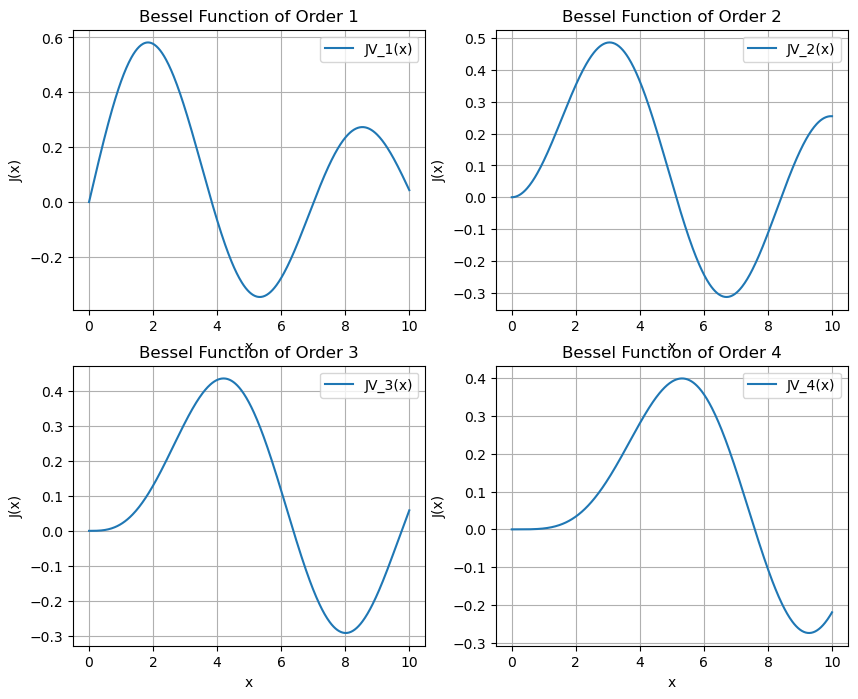

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import jv

# Values for x ranging from 0 to 10
x = np.linspace(0, 10, 500)

# Values for a from 1 to 4
orders = [1, 2, 3, 4]

# Make a figure of 2 by 2 for the mosaic and flatten the axis like done in previous question
fig, ax = plt.subplots(2, 2, figsize=(10, 8))
ax = ax.flatten()

# Plot the Bessel differential equation for all values of a
for i, a in enumerate(orders): # enumerate makes a set of (i,a) so the index and the value
    y = jv(a, x) # Use scipy function with values a and variable x
    #For each a make a seperate plot:
    ax[i].plot(x, y, label=f'JV_{a}(x)')
    ax[i].set_title(f'Bessel Function of Order {a}')
    ax[i].set_xlabel('x')
    ax[i].set_ylabel('J(x)')
    ax[i].legend()
    ax[i].grid(True)

# Save figures as png
fig.savefig("bessel.png", transparent=True)

# Made comment because its not needed since image is attached, but for checking # can be deleted
#plt.show()

## Image of all four figures

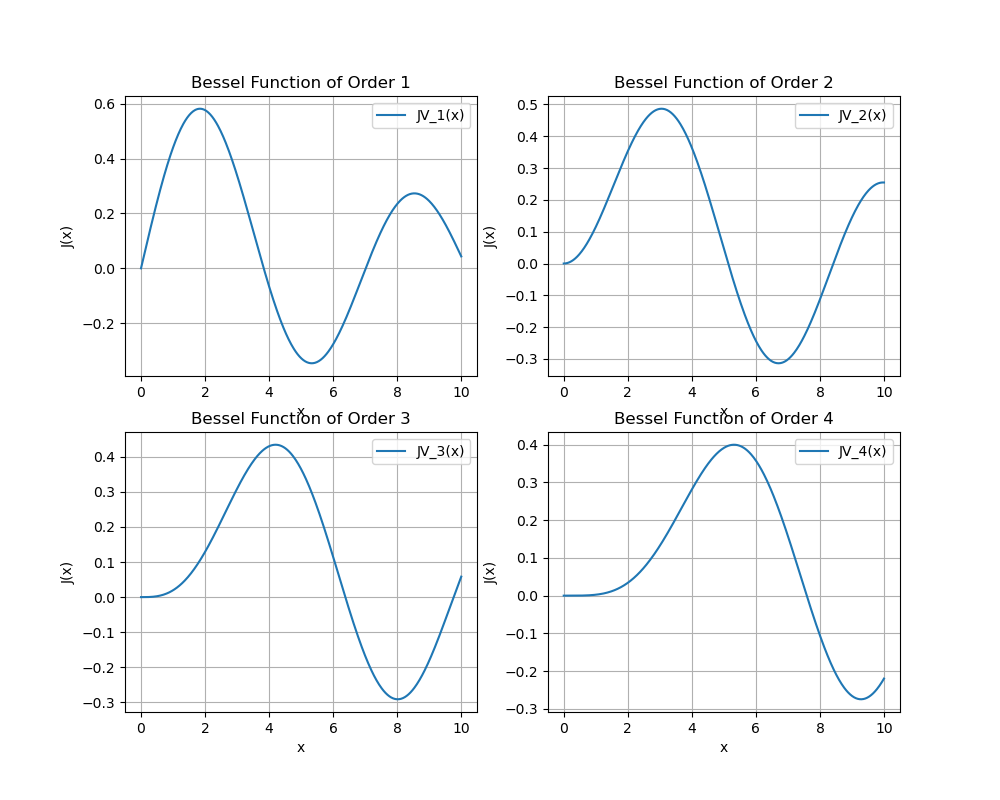

In [9]:
# Leave unaltered
totalpoints += 3
currentpoints += 0.0

### Matplotlib, the right way (2 pt)  <font color='red'><b>HOMEWORK</b></font>

The following table contains the measurements of distances and velocities, including their uncertainties, for a small sample of galaxies. The table is given in the form of a Python list.

From your previous coursework, you have done chi-squared fitting to fit the following data without uncertainties. If considering the uncertainties during the fitting process, the slope of a best fit line through the data gives a value for the Hubble constant.

$$H_0 = 67.8 (km/s)/Mpc$$

```
    d(Mpc)    v(km/s)    error in d    error in v
    ==============================================
    18.49      2094.75    0.3           100
    35.48      2320.87    2.2           120
    ........
```
```python
    data = [
    18.49,     2094.75,    0.3,           100,
    35.48,     2320.87,    2.2,           120,
    35.48,     1224.9,     3.0,           80,
    11.34,     872.13,     1.2,           80,
    7.12,      432.2,      0.4,           70,
    9.82,      751,        0.3,           75,
    23.66,     1410,       2.3,           70,
    44,        2700,       4.0,           110,
    66.7,      5292,       5.3,           120,
    52.4,      2550,       5.2,           100,
    55,        5253,       6.1,           150,
    25.6,      2419,       3.2,           110,
    26.19,     2158,       2.8,           110
    ]
```

<font color='red'>In this question, you have to use the OO interface of Matplotlib to create your plot, or 1.0pt will be deducted.</font>

* Use slicing syntax to unpack ``data`` into separate variables for distance and velocity, as well as their corresponding errors.
* Create a plot for this data. Add error bars with method `errorbar() <matplotlib.axes.Axes.errorbar>`
* Plot also a line which represents the Hubble relation between distance and velocity  as a line through the origin, with a slope equal to $H_0$
* Add the value of $H_0$ to the legend using LaTex math mode
  
**Script and plot**:

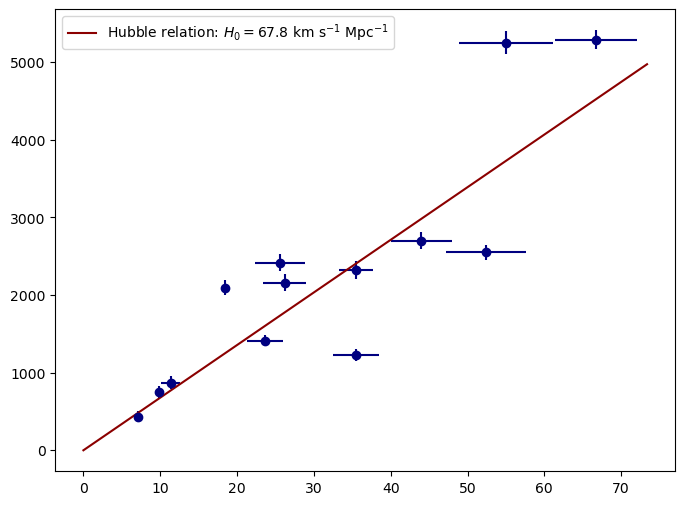

In [10]:
import matplotlib.pyplot as plt
import numpy as np

data = [
    18.49,     2094.75,    0.3,           100,
    35.48,     2320.87,    2.2,           120,
    35.48,     1224.9,     3.0,           80,
    11.34,     872.13,     1.2,           80,
    7.12,      432.2,      0.4,           70,
    9.82,      751,        0.3,           75,
    23.66,     1410,       2.3,           70,
    44,        2700,       4.0,           110,
    66.7,      5292,       5.3,           120,
    52.4,      2550,       5.2,           100,
    55,        5253,       6.1,           150,
    25.6,      2419,       3.2,           110,
    26.19,     2158,       2.8,           110
]

# Slicing works like [start::steps] so the starting index indicates which would be the first value in the array
# the steps are always four to make sure it is the next item from that same column
d = np.array(data[0::4]) # distances (Mpc) 1st column
v = np.array(data[1::4]) # velocities (km/s) 2nd column
d_err = np.array(data[2::4]) # distance errors 3rd column
v_err = np.array(data[3::4]) # velocity errors 4th column

# Make figure and axis
fig, ax = plt.subplots(figsize=(8,6))
# add datapoints (as dots) and corresponding errorbars in x and y direction
ax.errorbar(d, v, xerr=d_err, yerr=v_err, fmt='o', color='navy')


# Plot hubble relation line
H0 = 67.8  # km/s/Mpc
x = np.linspace(0, max(d)*1.1, 100) # Make an array containing all values from 0 to a bit above the maximum of the distances (100 numbers total)
y = H0 * x # Calculate y for each x value
ax.plot(x,y, label=f'Hubble relation: $H_0 = {H0} ~ \mathrm{{km ~ s^{{-1}} ~ Mpc^{{-1}} }}$', color = 'darkred') # Use latex for H_0 and the unit

plt.legend()


In [11]:
# Leave unaltered
totalpoints += 2
currentpoints += 0.0

## Finishing up

**Please read the section about your report in the task documentation very carefully before submitting it to BrightSpace.**

------------

## T.A. Grading


In [12]:
# Leave unaltered
taskgrade = round(10*currentpoints/totalpoints, 1) if totalpoints != 0 else 0
print(f"Total number of points: {totalpoints}. Student score: {currentpoints}.  Task Grade = {taskgrade}")

Total number of points: 18. Student score: 0.0.  Task Grade = 0.0
